Group K-Fold

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GroupKFold
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

In [ ]:
# questa funzione crea un dataset fittizzio

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=0,
    random_state=42
)

# facciamo 50 gruppi per 20 elementi
groups = np.repeat(np.arange(50), 20)

In [3]:
K = 5

In [4]:
model = LogisticRegression()

In [ ]:
acc_kf = []
kf = KFold(n_splits=K, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    acc_kf.append(acc)

In [11]:
acc_gkf = []

gkf = GroupKFold(n_splits=K, shuffle=True, random_state=42)

for train_index, test_index in gkf.split(X, y, groups=groups):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    acc_gkf.append(acc)

In [13]:
mean_kf = np.mean(acc_kf)
std_kf = np.std(acc_kf)
mean_gkf = np.mean(acc_gkf)
std_gfk = np.std(acc_gkf)

print(f"K-Fold Standard:\n\tMedia:\t{mean_kf:.4f}\n\tstd:\t{std_kf:.4f}\n\tAccuracy:\t{np.round(acc_kf, 4)}")
print(f"K-Fold Stratified:\n\tMedia:\t{mean_gkf:.4f}\n\tstd:\t{std_gfk:.4f}\n\tAccuracy:\t{np.round(acc_gkf, 4)}")

K-Fold Standard:
	Media:	0.8110
	std:	0.0215
	Accuracy:	[0.77  0.82  0.825 0.81  0.83 ]
K-Fold Stratified:
	Media:	0.8160
	std:	0.0262
	Accuracy:	[0.845 0.785 0.84  0.785 0.825]


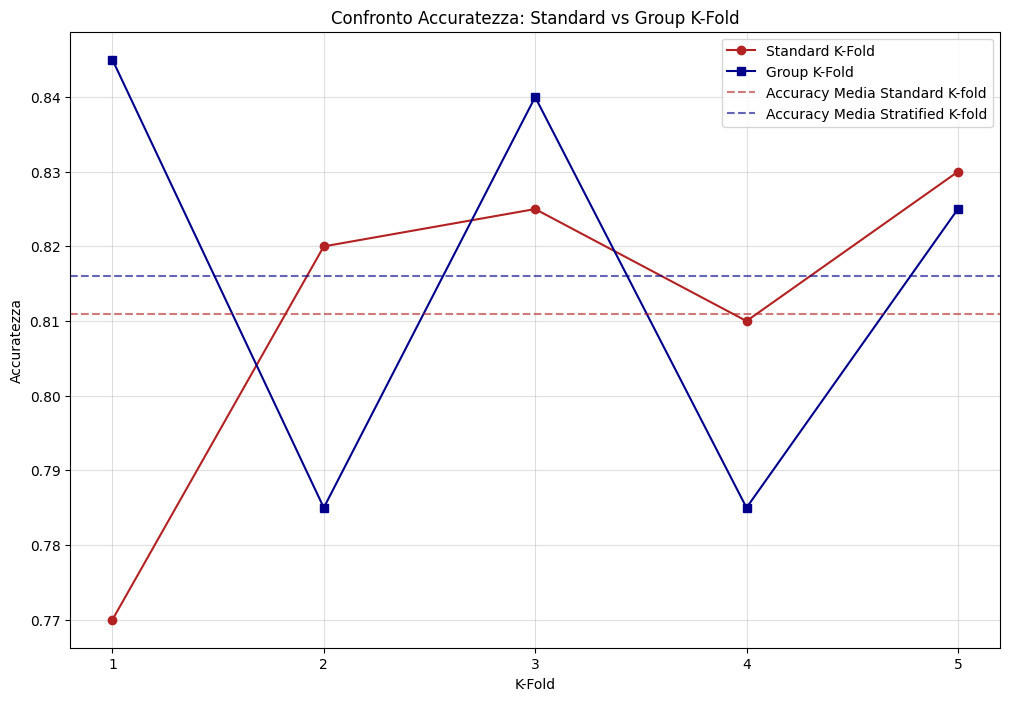

In [14]:
plt.figure(figsize=(12,8))

plt.plot(np.arange(1, K+1), acc_kf, marker="o", linestyle="-", color="firebrick", label="Standard K-Fold")
plt.plot(np.arange(1, K+1), acc_gkf, marker="s", linestyle="-", color="darkblue", label="Group K-Fold")

plt.axhline(mean_kf, color="firebrick", linestyle="--", alpha=0.6, label="Accuracy Media Standard K-fold")
plt.axhline(mean_gkf, color="darkblue", linestyle="--", alpha=0.6, label="Accuracy Media Stratified K-fold")

plt.xticks(range(1, K+1))

plt.title(f"Confronto Accuratezza: Standard vs Group K-Fold")
plt.xlabel("K-Fold")
plt.ylabel("Accuratezza")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()